Just getting started on some analysis testing! - Aidan

In [2]:
import pandas as pd

In [6]:
df = pd.read_csv("RelevantData.csv")
df.head()

,ResponseId,PID,HS_1,HS_2,HS_3,FM_1,FM_2,GM_1,GM_2,Dif_import1,Dif_import2,Dif_impos1,Dif_impos2,CurrentCountry_Cleaned,K12Country_Cleaned,Age,Sex,Ethnicity,Language
0,R_rr0W1Eib65n6Oxr,64469d49bd962313f4ecdb1f,1,6,6,2,3,4,4,2,2,3,2,Germany,Germany,22,Female,White,German
1,R_O8SJG906vuCGx7X,643850d960ae67c75c0198df,6,5,5,4,2,4,5,4,5,2,2,Germany,Germany,25,Male,White,English
2,R_6WqWfxshvfqOtYl,6408c1b54a500c8d81f12d6e,2,3,4,4,5,6,5,5,4,5,3,Germany,Germany,24,Male,White,German
3,R_2uWzbfJ5XsTAZCw,61111091292799d97f76a5a3,5,3,2,3,3,4,4,5,5,2,2,Germany,Germany,19,Female,White,German
4,R_3rsbkruurP6IEXT,6438576b1860de7fc057113d,4,2,5,1,1,5,6,2,3,5,4,Germany,Germany,18,Female,White,German


In [10]:
df["country"] = df["CurrentCountry_Cleaned"]
df["country"].value_counts()

country
USA             150
South Africa    149
Mexico          141
Spain           137
UK              120
Germany         104
Scandinavia      52
Name: count, dtype: int64

Creating group columns 

Flipping HS_1 as the question is flipped

In [7]:
df["help_seeking"] = df[["HS_1", "HS_2", "HS_3"]].mean(axis=1)
df["fixed_mindset"] = df[["FM_1", "FM_2"]].mean(axis=1)
df["growth_mindset"] = df[["GM_1", "GM_2"]].mean(axis=1)

df["difficulty_important"] = df[["Dif_import1", "Dif_import2"]].mean(axis=1)
df["difficulty_impossible"] = df[["Dif_impos1", "Dif_impos2"]].mean(axis=1)

Means by country

In [11]:
df.groupby("country")[[
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]].mean()

,growth_mindset,fixed_mindset,difficulty_important,difficulty_impossible,help_seeking
country,,,,,
Germany,3.649038,3.105769,3.543269,2.432692,3.782051
Mexico,4.656028,2.570922,3.886525,2.606383,4.262411
Scandinavia,3.942308,2.769231,3.403846,2.173077,3.596154
South Africa,4.842282,2.661074,4.208054,2.271812,4.378076
Spain,4.014599,2.868613,3.503650,2.616788,4.063260
UK,4.025000,2.725000,3.795833,2.333333,3.855556
USA,4.333333,2.606667,3.880000,2.396667,3.995556


some basic box plots

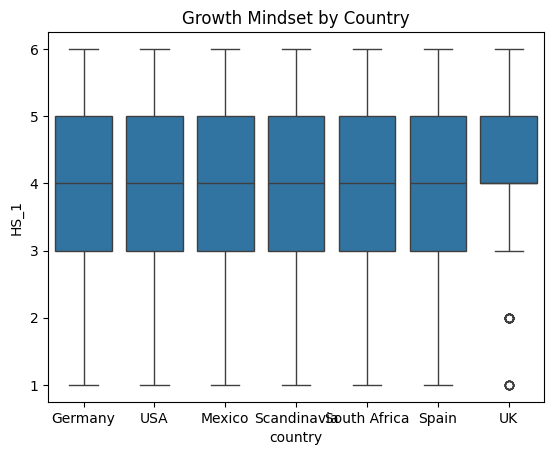

In [25]:
plt.figure()
sns.boxplot(data=df, x="country", y="HS_1")
plt.title("Growth Mindset by Country")
plt.show()

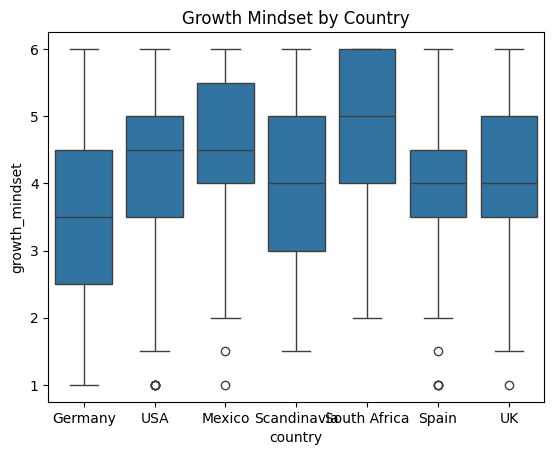

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(data=df, x="country", y="growth_mindset")
plt.title("Growth Mindset by Country")
plt.show()

bit of an issue with the names here...

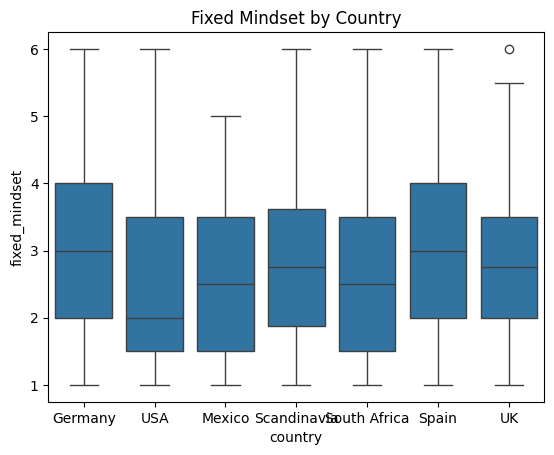

In [14]:
plt.figure()
sns.boxplot(data=df, x="country", y="fixed_mindset")
plt.title("Fixed Mindset by Country")
plt.show()

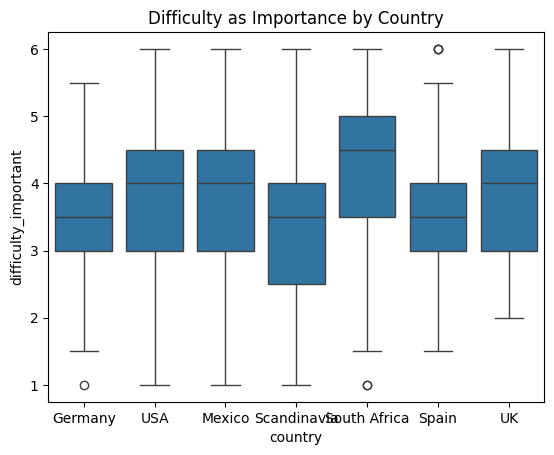

In [16]:
plt.figure()
sns.boxplot(data=df, x="country", y="difficulty_important")
plt.title("Difficulty as Importance by Country")
plt.show()

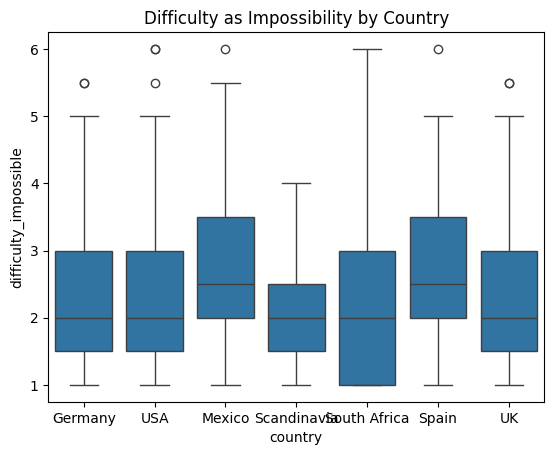

In [17]:
plt.figure()
sns.boxplot(data=df, x="country", y="difficulty_impossible")
plt.title("Difficulty as Impossibility by Country")
plt.show()

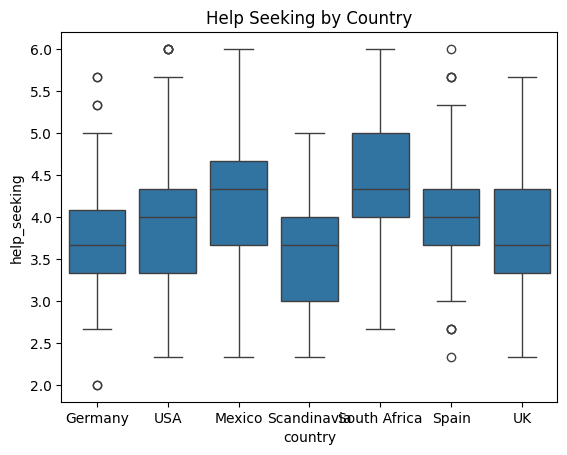

In [18]:
plt.figure()
sns.boxplot(data=df, x="country", y="help_seeking")
plt.title("Help Seeking by Country")
plt.show()

We probably need to do something to handle outliers here, perhaps? 

Also figuring out a cleaner way to present all of this: 

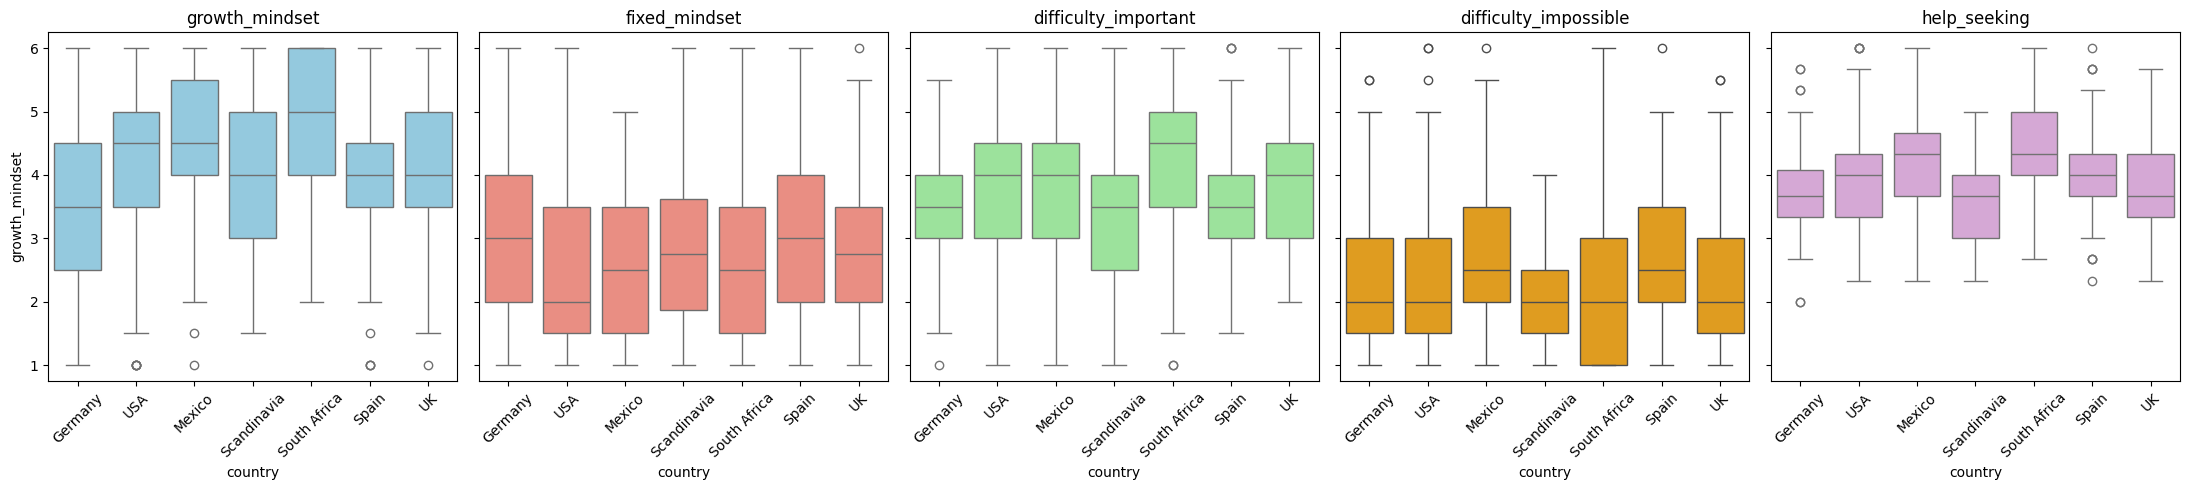

In [21]:
variables = [
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]

colors = ["skyblue", "salmon", "lightgreen", "orange", "plum"]

fig, axes = plt.subplots(1, len(variables), figsize=(22, 5), sharey=True)

for i, var in enumerate(variables):
    sns.boxplot(
        data=df,
        x="country",
        y=var,
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Now moving on to some basic anova analysis

In [22]:
import scipy.stats as stats

variables = [
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]

for var in variables:
    groups = [group[var].dropna() for name, group in df.groupby("country")]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"\n{var}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.6f}")


growth_mindset
F-statistic: 16.7492
p-value: 0.000000

fixed_mindset
F-statistic: 2.3695
p-value: 0.028196

difficulty_important
F-statistic: 7.9845
p-value: 0.000000

difficulty_impossible
F-statistic: 2.4494
p-value: 0.023566

help_seeking
F-statistic: 13.9108
p-value: 0.000000
